# Лабораторная работа: обучение многообразий

# PCA

В этом блоке вам предстоит выполнить задания, касающиеся метода главных компонент (`PCA`).

## Теоретическая часть

Пусть на вход подаются центрированные данные
$$
x_i = \begin{pmatrix}
x_{i1} \\ x_{i2} \\ \vdots \\ x_{ip}
\end{pmatrix} \in \mathbb R^{p \times 1}, \quad i \in \{1, \ldots, n\}, \quad \sum\limits_{i = 1}^n x_i = 0.
$$
Пусть также $X$ — матрица размера $n \times p$ — матрица объекты-признаки (внимание: объекты расположены в матрице $X$ по строкам), $W$ – матрица размера $p \times l$ из ортонормированных базисных векторов (их координаты записаны по столбцам) линейного подпространства $\mathbb R^l$ пространства $\mathbb R^p$, в которое мы хотим «вложить» исходные объекты, $Z$ — матрица размера $n \times l$ — матрица координат старых объектов в новом базисе. Мы определили функцию потерь ($l_2$-потери) следующим образом:

$$
L(W) = \|X^T - WZ^T\|^2_F = \sum\limits_{i = 1}^n \|x_i - Wz_i\|^2.
$$

На лекции мы обсудили построение первой главной компоненты, минимизируя выражение

$$
L(W) = \sum\limits_{i = 1}^n\|x_i - w_1z_{i1}\|^2.
$$

При условии, что $w_1^Tw_1 = 1$, мы получили, что

$$
z_{i1} = x_i^Tw_1,
$$

то есть что новая координата есть проекция на $w_1$, и что $w_1$ — собственный вектор выборочной ковариационной матрицы

$$
\Sigma = \frac{1}{n}X^TX,
$$

отвечающей наибольшему собственному значению.



## Задача 1

Вам требуется построить первые две главные компоненты, объяснить сособ их получения, а также их геометрический и статистический смыслы. Для этого:

1.   Составьте минимизируемый функционал.
2.   Докажите, что новые координаты (счеты) — это проекции исходных данных на соотвествующие векторы $w_1$, $w_2$.
3. Докажите, что $w_1$, $w_2$ — это собственные векторы выборочной ковариационной матрицы, отвечающие двум наибольшим собственным значениям, по убыванию, соответственно.
4. Покажите, что статистический смысл упомянутых выше собственных чисел — значение выборочных дисперсий соответствующих (новых) координат.

**Решение:**
# **1**
  Мы хотим спроецировать данные X (n x p) на двумерное пространство, натянутое на ортонормированные векторы $w_1$ и $w_2$ (p x 1 каждый). Функционал потерь — это сумма квадратов расстояний от исходных точек до их проекций на плоскость.

Математически запишем так:

$$L(W) = \sum\limits_{i = 1}^n\|x_i - Wz_{i}\|^2,$$

где W = [$w_1$, $w_2$] — матрица p x 2, а $z_i$ — координаты i-го объекта в новом базисе (вектор 2 x 1)

Учитывая, что $z_i = W^T x_i$ (проекция), функционал принимает вид:
$$L(W) = \sum\limits_{i = 1}^n\|x_i - WW^Tx_i\|^2$$

# **2**

Возьмем производную по $z_{i1}$ и приравняем к нулю:
$$\frac{∂}{∂z_{i1}} ( (x_i - w_1 z_{i1})^T (x_i - w_1 z_{i1}) ) = 0$$

$$2 (x_i - w_1 z_{i1})^T (-w_1) = 0$$

$$(x_i^T - z_{i1} w_1^T) w_1 = 0$$

$$x_i^T w_1 - z_{i1} (w_1^T w_1) = 0$$

Так как $w_1$ ортонормирован ($w_1^T w_1 = 1$), получаем:
$$x_i^T w_1 = z_{i1}$$

Что и является скалярным произведением, т.е. проекцией вектора $x_i$ на направление $w_1$

# **3**

Минимизация функционала L(W) эквивалентна максимизации дисперсии проекций. Для первой компоненты:

$$D(z_1) = D(X w_1) = w_1^T (X^T X) w_1 = n ⋅ w_1^T Σ w_1$$

При ограничении $w_1^T w_1 = 1$. Используя метод множителей Лагранжа:

$$L = w_1^T Σ w_1 - λ (w_1^T w_1 - 1)$$

$$\frac{∂L}{∂w_1} = 2 Σ w_1 - 2 λ w_1 = 0$$

значит $Σ w_1 = λ w_1$.

Следовательно, $w_1$ - это собственный вектор ковариационной матрицы Σ. Чтобы максимизировать дисперсию, мы выбираем собственный вектор с наибольшим собственным значением λ1. Дисперсия проекции равна λ1.

Для второй компоненты $w_2$ мы добавляем условие ортогональности $w_2^T w_1 = 0$. Решая задачу оптимизации с двумя ограничениями, мы получаем, что $w_2$ - это второй собственный вектор, соответствующий второму по величине собственному значению λ2.

# **4**

Из предыдущего пункта мы получили: $D(z_1) = λ1$ и $D(z_2) = λ2$.
Таким образом, собственные числа выборочной ковариационной матрицы - это выборочные дисперсии соответствующих главных компонент (новых координат). Они показывают, какую долю общей дисперсии исходных данных "объясняет" каждая главная компонента.

## Задача 2

Предыдущий подход хорошо работает в случае, когда $n$ сильно больше $p$. В противном случае разумнее рассматривать тоже симметричную матрицу $XX^T$. Ваша задача, взяв конкретную матрицу $X$ (скажем, размера $3 \times 3$, но можно и в общем виде), показать, что

1.   Существует ортогональная матрица $U$, что

$$
U^TXX^TU = \Lambda,
$$

где последняя матрица — диагональная.

2.   Верно равенство

$$
XX^TU = U \Lambda,
$$

а значит и равенство

$$
X^TXX^TU = X^TU \Lambda,
$$

откуда

$$
(X^TX)(X^TU) = X^TU \Lambda
$$

и $X^TU$ — матрица из собственных векторов для $X^TX$.

3. Показать, что столбцы матрицы $X^TU$ ортогональны, но не ортонормированы.

4. Найти нормы столбцов $X^TU$, привести преобразование к ортогональному. Получить аналог `PCA`.

5. Показать численно (на конкретной матрице) с использованием, например, `numpy`.

**Решение:**
# **1**

Матрица $XX^T$ - это симметричная матрица размера n x n. Для любой симметричной матрицы существует ортогональная матрица U (состоящая из ее собственных векторов), которая диагонализирует ее:
$$
U^T(XX^T)U =  \Lambda,
$$
где Λ — диагональная матрица собственных значений.

# **2**

$$U^T X X^T U = Λ$$

$$U U^T X X^T U = U Λ$$

Так как U ортогональна ($U U^T = I$), получаем
$$XX^T U=UΛ$$

$$X^T X X^T U = X^T U Λ$$

Если обозначить $V = X^T U$, то мы имеем:

$$(X^T X)V = V Λ$$

Это означает, что столбцы матрицы V являются собственными векторами матрицы $X^T X$ (матрицы Грама), а Λ — матрицей ее собственных значений (тех же самых, что и у $XX^T$).

# **3**

Ортогональность, но не ортонормированность столбцов $X^T U$

Столбцы $V = X^T U$ ортогональны. Докажем это.

Рассмотрим

$$V^T V = (X^T U)^T (X^T U) = U^T X X^T U = U^T (U \Lambda U^T) U = (U^T U) \Lambda (U^T U) = I \Lambda I = \Lambda$$

Так как Λ диагональна, $V^T V$ - диагональная матрица. Это и означает, что столбцы V ортогональны. Однако их длины (нормы) равны квадратным корням из собственных значений $\sqrtλ_i$, что в общем случае не равно 1. Поэтому они не ортонормированы.

# **4**
Норма j-го столбца $v_j$ равна $||v_j|| = \sqrtλ_j$. Чтобы получить ортонормированный базис для PCA, нужно нормировать столбцы:

$$W=VΛ^{-1/2}$$

где $Λ^{-1/2}$ - диагональная матрица с элементами $1/\sqrtλ_j$ на диагонали.

тогда $W^T W = I$, и это будут главные компоненты. Новые координаты (счеты) вычисляются как:
$Z = X W$

In [ ]:
import numpy as np

X = np.array([
    [1., 3., 0.],
    [3., 0., 3.],
    [0., 3., 1.]
])

XXT = X @ X.T
XTX = X.T @ X

print("XX^T =")
print(XXT)

print("\nX^T X =")
print(XTX)

eigvals, U = np.linalg.eigh(XXT)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
U = U[:, idx]

W = []
for i, lam in enumerate(eigvals):
    if lam > 1e-12:
        wi = X.T @ U[:, i] / np.sqrt(lam)
        W.append(wi)

W = np.column_stack(W)

print("\nСобственные значения:")
print(eigvals)

print("\nU =")
print(U)

print("\nW =")
print(W)

print("\nW^T W =")
print(W.T @ W)

print("\nПроверка X^T X w = lambda w:")
for i in range(W.shape[1]):
    print((XTX @ W[:, i]) - eigvals[i] * W[:, i])

XX^T =
[[10.  3.  9.]
 [ 3. 18.  3.]
 [ 9.  3. 10.]]

X^T X =
[[10.  3.  9.]
 [ 3. 18.  3.]
 [ 9.  3. 10.]]

Собственные значения:
[22.77200187 14.22799813  1.        ]

U =
[[-5.28450837e-01  4.69829451e-01  7.07106781e-01]
 [-6.64439182e-01 -7.47342340e-01 -1.11022302e-16]
 [-5.28450837e-01  4.69829451e-01 -7.07106781e-01]]

W =
[[-5.28450837e-01 -4.69829451e-01  7.07106781e-01]
 [-6.64439182e-01  7.47342340e-01  1.33226763e-15]
 [-5.28450837e-01 -4.69829451e-01 -7.07106781e-01]]

W^T W =
[[ 1.00000000e+00  1.89839812e-16 -7.44923805e-16]
 [ 1.89839812e-16  1.00000000e+00  9.86683773e-16]
 [-7.44923805e-16  9.86683773e-16  1.00000000e+00]]

Проверка X^T X w = lambda w:
[-1.77635684e-15 -5.32907052e-15 -1.77635684e-15]
[ 8.88178420e-16  3.55271368e-15 -1.77635684e-15]
[-8.88178420e-16  2.18713936e-14  4.32986980e-15]


## Практическая часть

Рассмотрим применение `PCA` в разрезе работы с зашумленными данными. Наша цель — выяснить, можно ли при помощи метода каким-то образом избавляться от шума в данных. Прежде чем двигаться дальше к конкретике, предположите, осуществимо ли это и, если ответ положительный, попробуйте предложить конкретный способ (с обоснованием).

Предположим следующую ситуацию: решается задача классификации, есть некоторый тренировочный набор данных (эталонный, возможно синтетический), на котором обучается модель классификации. Данные же для предсказания поступают в некотором "зашумленном" виде: например, барахлит датчик/некачественная аппаратура/проблемы канала передачи данных, etc. Для повышения качества классификации разумно попробовать избавиться от шума в данных. Попробуем смоделировать такую ситуацию.

**Примечание:** в качества классификатора будет выступать [логистическая регрессия](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html). В рамках этой работы не будем вникать в суть самого метода, но будем использовать его как некоторый абстрактный классификатор, который поможет нам численно оценить то, насколько хорошо мы избавились от шума.

Будем работать с `FashionMNIST`

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(np.float64(-0.5), np.float64(419.5), np.float64(279.5), np.float64(-0.5))

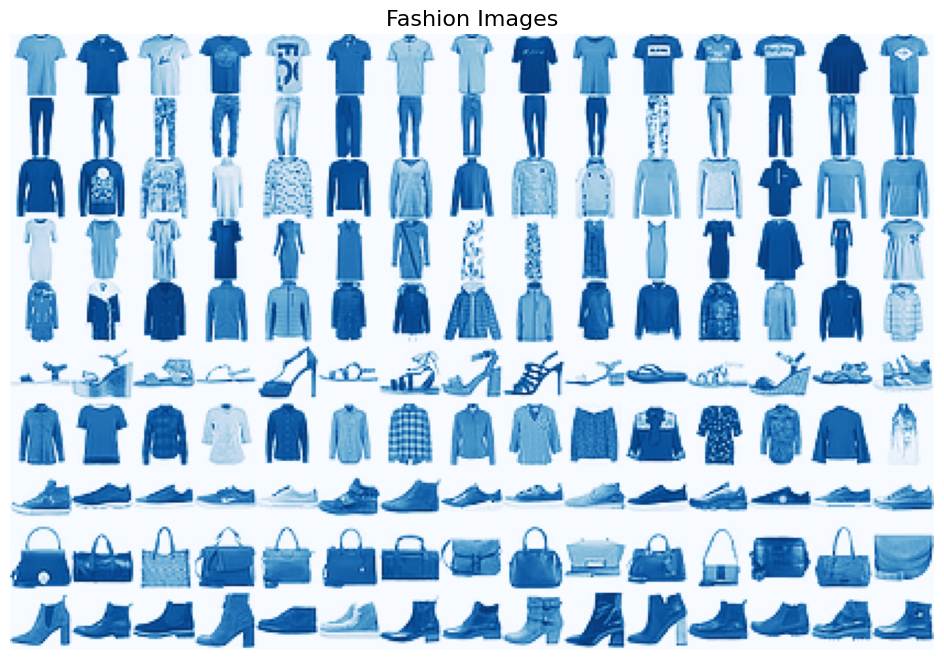

In [ ]:
classes = sorted(np.unique(train_labels).astype(int))
h = w = 28
n_samples = 15

fig, ax = plt.subplots(figsize=(18, 8))
fashion_sample = np.empty(shape=(h * len(classes),
                                 w * n_samples))

for row, label in enumerate(classes):
    label_idx = np.argwhere(train_labels == label).squeeze()
    sample_indices = np.random.choice(label_idx, size=n_samples, replace=False)
    i = row * h
    for col, sample_idx in enumerate(sample_indices):
        j = col * w
        sample = train_images[sample_idx].reshape(h, w)
        fashion_sample[i:i+h, j:j + w] = sample

ax.imshow(fashion_sample, cmap='Blues')
ax.set_title('Fashion Images', fontsize=16)
plt.axis('off')

Набор данных содержит изображения различных предметов одежды: футболки, штаны, кофты, платья, обувь различного вида, etc. Всего $10$ классов. Для меньших временных затрат будем использовать только данные из тестовой части исходного набора данных (всего $10$ тысяч объектов).

In [ ]:
X = test_images.reshape(len(test_images), -1)
y = test_labels

При помощи `train_test_split` разбейте набор данных на тренировочную и тестовую части в соотношении `80:20`. Используйте стратификацию по колонке отклика.

**Примечание:** здесь и далее для воспроизводимости результатов и корректного сравнения результатов экспериментов имеет смысл фиксировать `random_state`.

In [ ]:
from sklearn.model_selection import train_test_split

# Установка random_state для воспроизводимости
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (8000, 784)
Размер тестовой выборки: (2000, 784)


Обучите модель `LogisticRegression` со следующими параметрами: `max_iter=2000, tol=0.001` на тренировочных данных. При помощи `f1_score` с параметром `average='weighted'` оцените модель на тестовых данных.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clf = LogisticRegression(max_iter=2000, tol=0.001, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
score_clean = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score на чистых данных: {score_clean:.4f}")

F1-score на чистых данных: 0.7381


**Вопрос:** как работает `f1_score` и что показывает данная метрика? Опишите ее плюсы и минусы. Что означает параметр `average='weighted'`? Какие еще бывают параметры, зачем и когда они используются?

**Ваш ответ:**

**Как работает:** F1-score — это среднее гармоническое между полнотой (recall) и точностью (precision). $$F1 = 2 * (precision * recall) / (precision + recall).$$ Он стремится к 1, когда и precision, и recall высоки.

**Что показывает:** Это метрика качества классификатора, особенно полезная для несбалансированных классов. Она "штрафует" модель, если у нее низкие значения или precision, или recall.

**Плюсы и минусы:**

**Плюсы:** Устойчива к несбалансированным классам (в отличие от accuracy), один число, удобное для сравнения моделей.

**Минусы:** Не учитывает истинно отрицательные ответы (TN). В некоторых задачах это может быть критично.


**average='weighted':** Вычисляет F1-score для каждого класса отдельно, а затем усредняет их, взвешивая по количеству объектов в каждом классе (поддержке). Это лучший выбор для многоклассовой классификации с несбалансированными классами.

**Другие параметры average:** 'macro' (простое среднее без учета веса классов), 'micro' (глобальный подсчет TP, FP, FN по всем классам), 'samples' (для многометочной классификации).

Добавьте к тестовым данным шум при помощи `np.random.normal(X_test, scale)`, где `scale` $\in \{50,100,150,200\}$. Визуально оцените результаты.

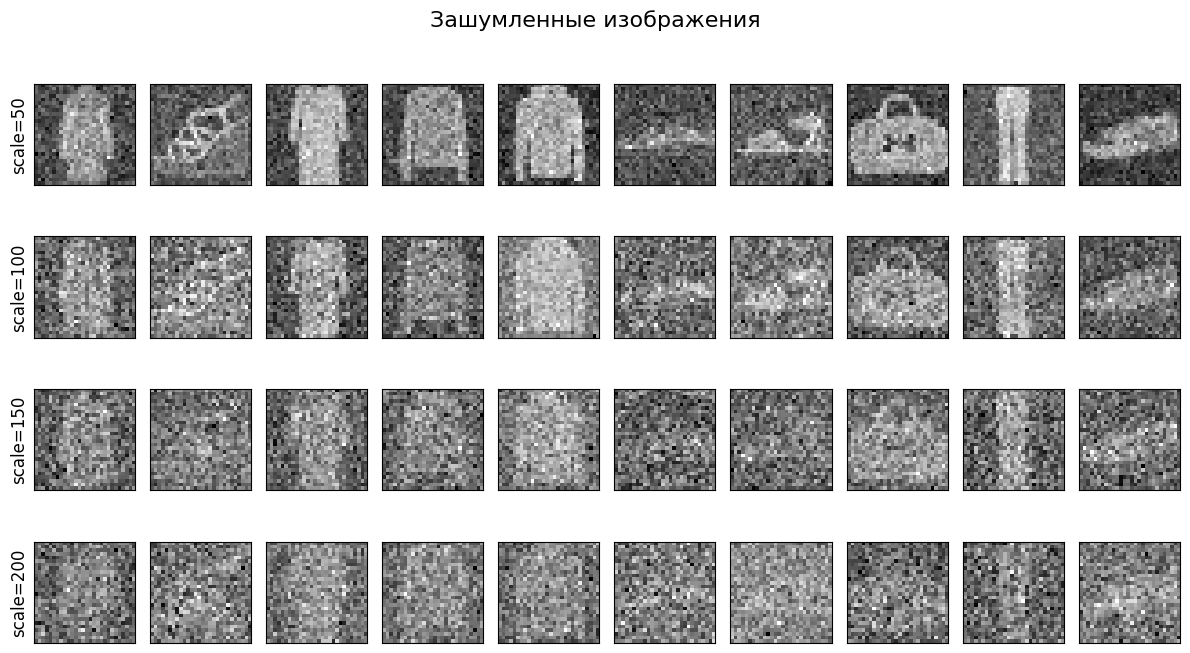

In [ ]:
# --- Добавление шума и оценка модели ---
scales = [50, 100, 150, 200]
scores_noisy = {}

# Добавления шума, визуализации и оценки
fig, axes = plt.subplots(4, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})
fig.suptitle("Зашумленные изображения", fontsize=16)

for i, scale in enumerate(scales):
    # Добавляем шум к тестовой выборке
    noise = np.random.normal(0, scale, X_test.shape)
    X_test_noisy = X_test + noise

    # Оценка модели
    y_pred_noisy = clf.predict(X_test_noisy)
    score = f1_score(y_test, y_pred_noisy, average='weighted')
    scores_noisy[scale] = score

    # Визуализация первых 10 зашумленных изображений для текущего scale
    for j in range(10):
        axes[i, j].imshow(X_test_noisy[j].reshape(28, 28), cmap='gray')
        if j == 0:
            axes[i, j].set_ylabel(f'scale={scale}', rotation=90, size='large')

plt.tight_layout()
plt.show()



**Ваши выводы:** Визуальное качество изображений упало. Появилась рябь. С увеличением scale рябь всё сильнее




Произведите предсказания для зашумленных тестовых данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.

In [ ]:
print("\nF1-score на зашумленных данных:")
for scale, score in scores_noisy.items():
    print(f"  scale={scale}: {score:.4f}")


F1-score на зашумленных данных:
  scale=50: 0.5291
  scale=100: 0.3788
  scale=150: 0.2803
  scale=200: 0.2358


**Ваши выводы:** При увеличении scale (уровня шума) качество классификации логистической регрессии резко падает.


Попробуем избавиться от шума при помощи метода главных компонент.

Обучите модель `PCA(explained_variance)` на зашумленных тестовых данных, где `explained_variance` $\in [0.1, 0.9]$ с шагом $0.1$. Уменьшите размерность зашумленных тестовых данных, а затем при помощи `.inverse_transform()` "восстановите" данные до приближенных исходных.


--- Эксперимент по шумоподавлению с PCA ---


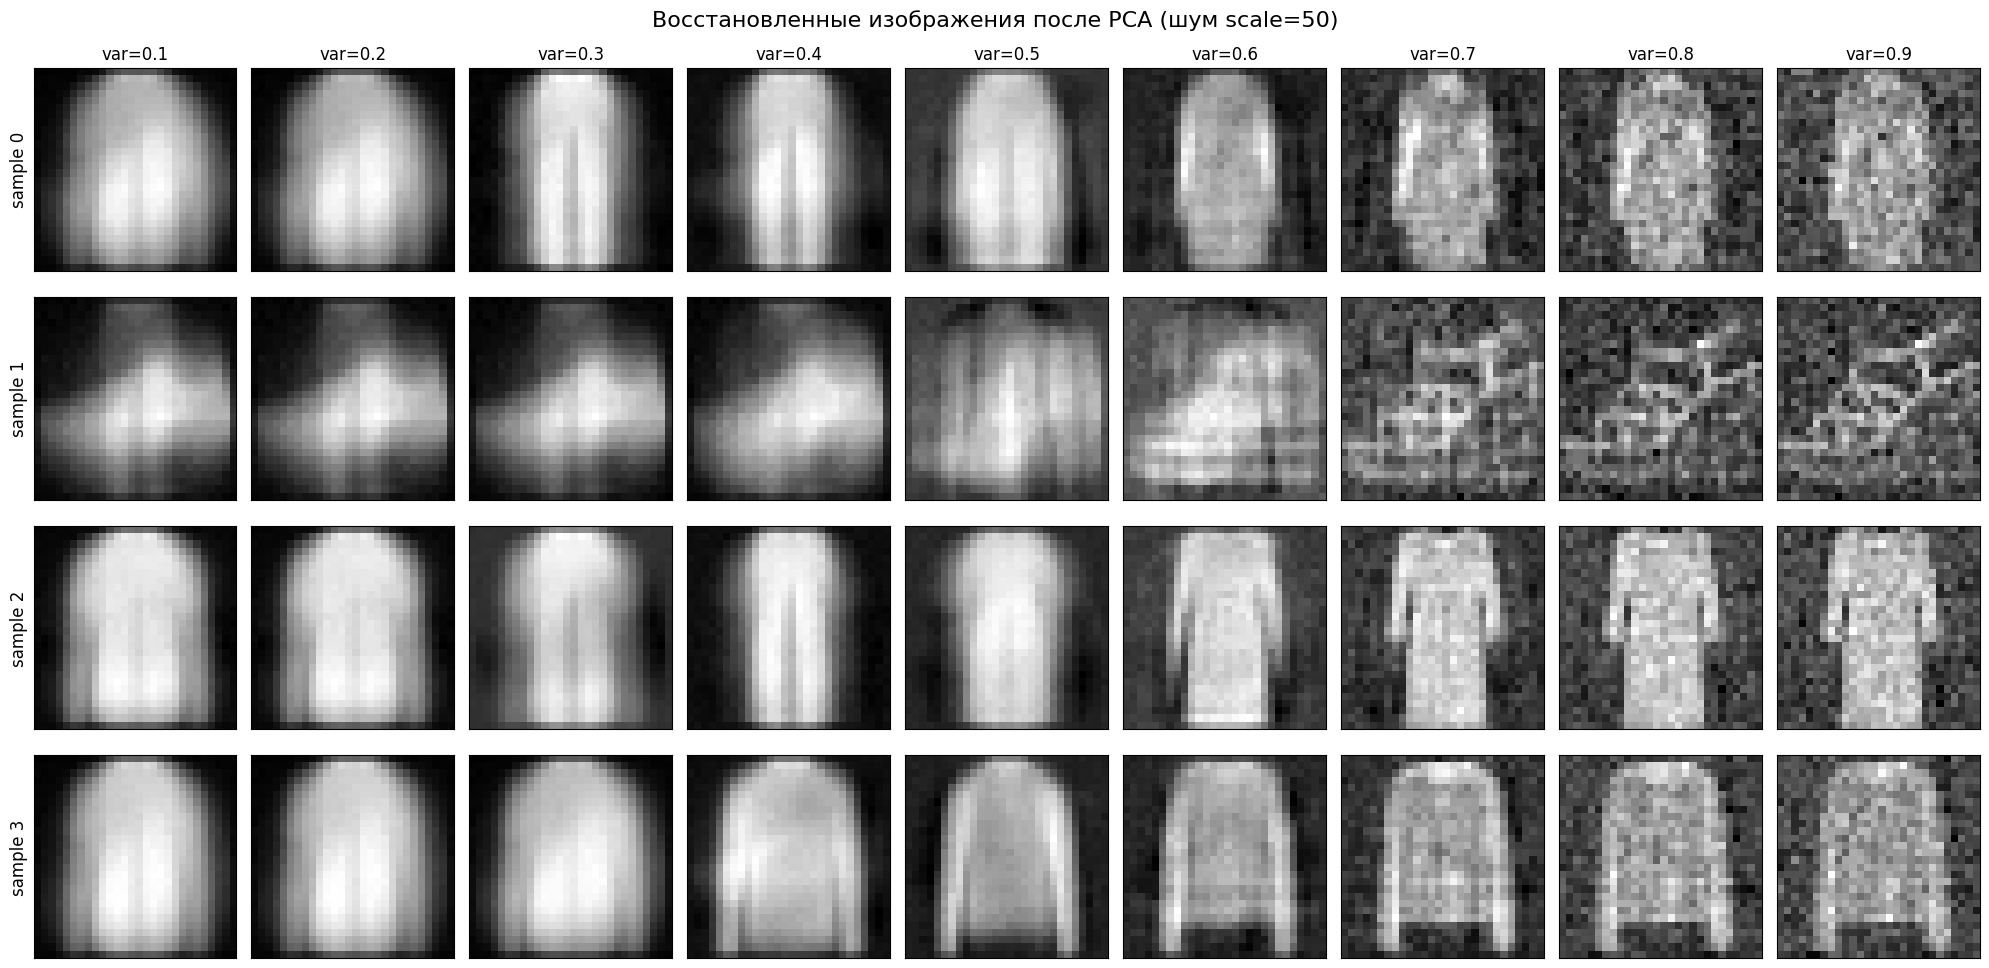

In [ ]:


from sklearn.decomposition import PCA

#Применение PCA для шумоподавления
explained_variances = np.arange(0.1, 1.0, 0.1)
scores_restored = {scale: [] for scale in scales} # для хранения результатов

# код для PCA, inverse_transform и оценки
fig, axes = plt.subplots(len(scales), len(explained_variances),
                         figsize=(20, 10), subplot_kw={'xticks': [], 'yticks': []})
fig.suptitle("Восстановленные изображения после PCA (шум scale=50)", fontsize=16)

# Для демонстрации возьмем один уровень шума (scale=50) и разные объясненные дисперсии
scale_for_demo = 50
noise = np.random.normal(0, scale_for_demo, X_test.shape)
X_test_noisy = X_test + noise

for i, ev in enumerate(explained_variances):
    pca = PCA(n_components=ev, random_state=RANDOM_STATE)
    # Обучаем PCA на зашумленных данных
    X_test_pca = pca.fit_transform(X_test_noisy)
    # Восстанавливаем данные
    X_test_restored = pca.inverse_transform(X_test_pca)

    # Визуализируем восстановленные изображения для первых 5 строк
    for j in range(len(scales)):
        axes[j, i].imshow(X_test_restored[j].reshape(28, 28), cmap='gray')
        if j == 0:
            axes[j, i].set_title(f'var={ev:.1f}')
        if i == 0:
            axes[j, i].set_ylabel(f'sample {j}', rotation=90, size='large')

# Теперь проведем полноценный эксперимент для всех scale и ev
print("\n--- Эксперимент по шумоподавлению с PCA ---")
for scale in scales:
    noise = np.random.normal(0, scale, X_test.shape)
    X_test_noisy = X_test + noise

    for ev in explained_variances:
        pca = PCA(n_components=ev, random_state=RANDOM_STATE)
        X_test_pca = pca.fit_transform(X_test_noisy)
        X_test_restored = pca.inverse_transform(X_test_pca)

        y_pred_restored = clf.predict(X_test_restored)
        score = f1_score(y_test, y_pred_restored, average='weighted')
        scores_restored[scale].append(score)

plt.tight_layout()
plt.show()

**Ваши выводы:** После применения PCA изображения становятся более чёткими и разборчивыми. Шум заметно снижается, хотя и не исчезает полностью. Наилучший результат достигается по моему мнению при var=0.6

Произведите предсказания для очищенных от шума данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.


F1-score после шумоподавления с PCA:
        50      100     150     200
0.1  0.0702  0.0784  0.3090  0.5137
0.2  0.0702  0.4650  0.5753  0.4283
0.3  0.1355  0.6445  0.4240  0.3745
0.4  0.3983  0.5806  0.3879  0.3414
0.5  0.6585  0.5118  0.3738  0.3131
0.6  0.7179  0.4782  0.3512  0.2909
0.7  0.6824  0.4298  0.3290  0.2866
0.8  0.6107  0.4080  0.3031  0.2577
0.9  0.5776  0.3996  0.2953  0.2469


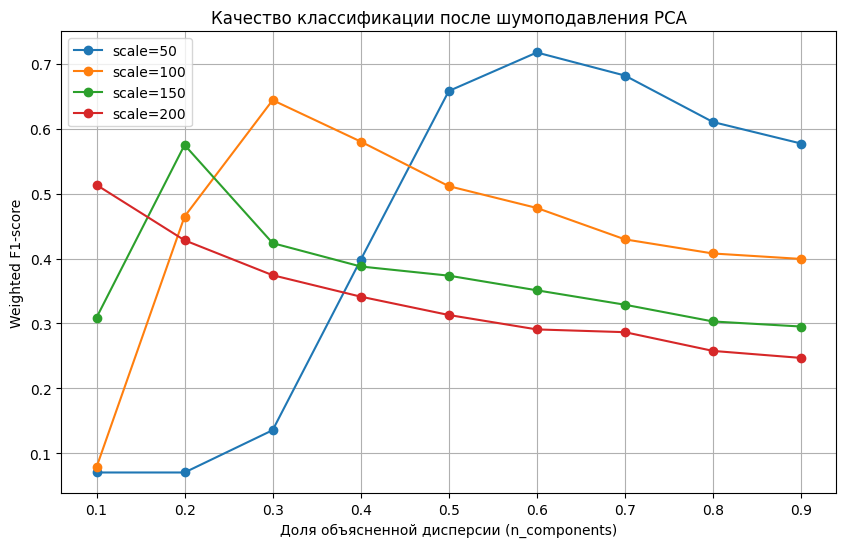

In [ ]:
# Визуализация результатов F1-score
# Создаем DataFrame для удобства
import pandas as pd

df_scores = pd.DataFrame(scores_restored, index=explained_variances)
print("\nF1-score после шумоподавления с PCA:")
print(df_scores.round(4))

# График зависимости F1-score от доли объясненной дисперсии для разных уровней шума
plt.figure(figsize=(10, 6))
for scale in scales:
    plt.plot(explained_variances, scores_restored[scale], marker='o', label=f'scale={scale}')
plt.xlabel("Доля объясненной дисперсии (n_components)")
plt.ylabel("Weighted F1-score")
plt.title("Качество классификации после шумоподавления PCA")
plt.legend()
plt.grid(True)
plt.show()



В качестве результата **НАГЛЯДНО** представьте получаемые значения `f1_score` в зависимости от используемого уровня шума и доли объясненной дисперции (таблицы, графики, диаграммы). Сделайте выводы.




**Ваши выводы:**


Чем выше уровень шума, тем меньше компонент нужно оставлять (меньше explained_variance). При сильном шуме большая часть данных зашумлена, и попытка сохранить больше информации приводит к сохранению шума


# t-SNE

В этом блоке вам предстоит выполнить задания, касающиеся `t-SNE`.

## Теоретическая часть

Напомним, что расстояние Кульбака--Лейблера между двумя распределенями $P = \{p_1, \ldots, p_n\}$, $Q = \{q_1, \ldots, q_n\}$ вычисляется как
$$
\mathbb{KL}(P|Q) = \sum\limits_{i=1}^np_i \log \frac{p_i}{q_i}.
$$

Пусть перплексия равна $k$. Положите $p_{i|j} = 1/k$ для $k$ ближайших соседей точки $j$ за исключением $j$, $p_{j|j} = 0$, как и остальные вероятности. Положите
$$
p_{ij} = \frac{p_{i|j} + p_{j|i}}{2n}.
$$

## Задача 1

Вычислите градиент $\mathbb{KL}$ в случае использования `SNE` и `t-SNE`.

**Ваш ответ:**


В SNE используются гауссовские распределения и в пространстве объектов, и в пространстве вложений:

Вероятности в пространстве объектов:

$$
p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}
$$

Вероятности в пространстве вложений:

$$
q_{j|i} = \frac{\exp(-\|y_i - y_j\|^2)}{\sum_{k \neq i} \exp(-\|y_i - y_k\|^2)}
$$

Функция потерь:

$$
C = \sum_i \text{KL}(P_i \| Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}
$$

Градиент:

$$
\frac{\partial C}{\partial y_i} = 2 \sum_j (p_{j|i} - q_{j|i} + p_{i|j} - q_{i|j})(y_i - y_j)
$$

#### Градиент для t-SNE

В t-SNE в пространстве вложений используется t-распределение Стьюдента с одной степенью свободы:

Симметризованные вероятности:

$$
p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}
$$

Вероятности в пространстве вложений (t-распределение):

$$
q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}
$$

Функция потерь:

$$
C = \text{KL}(P \| Q) = \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

Градиент:

$$
\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)(1 + \|y_i - y_j\|^2)^{-1}
$$

## Задача 2.1

В условиях предыдущей задачи самостоятельно реализуйте алгоритмы `SNE` и `t-SNE`. Проведите численные эксперименты для следующего набора данных:

In [1]:
import pandas as pd

link = 'https://courses.openedu.ru/assets/courseware/v1/6c89dd85d23926d43494d0e4dd968840/asset-v1:ITMOUniversity+INTROMLADVML+fall_2023_ITMO_mag+type@asset+block/94_16.csv'
data = pd.read_csv(link, header = None)
data.head()

,0,1,2,3,4,5,6,7,8,9
0,10.382991,-14.438544,-23.950798,-17.809813,2.480495,-15.743114,-9.112421,-27.390035,-11.955001,18.069910
1,18.987842,-13.071734,15.619164,-11.288528,-11.624820,14.845464,-4.924935,21.207876,-23.703025,4.440474
2,7.426000,-9.236580,-21.139348,6.732592,0.447684,-20.687020,-18.545136,7.758288,18.620790,-3.006755
3,10.718844,-10.240587,-20.604991,4.828083,-0.073568,-23.747055,-17.260869,7.074364,16.996747,-6.796469
4,10.662165,3.871777,12.384108,-1.921321,-1.990254,-5.469310,2.801321,-19.978717,23.414766,-2.654889


In [6]:
X = data.values
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy.optimize import minimize

In [9]:
class SNE:


    def __init__(self, n_components=2, perplexity=30, max_iter=100,
                 learning_rate=100, random_state=1):
        """
        Инициализация параметров SNE.

        """
        self.n_components = n_components
        self.perplexity = perplexity
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.embedding_ = None

    def _compute_pairwise_distances(self, X):
        """
        Вычисляет попарные евклидовы расстояния между точками.
        """
        n = X.shape[0]
        distances = np.zeros((n, n))

        for i in range(n):
            for j in range(i+1, n):
                distances[i, j] = np.sum((X[i] - X[j])**2)
                distances[j, i] = distances[i, j]
        return distances

    def _compute_p_conditional(self, distances, sigma, i):
        """
        Вычисляет условные вероятности p_{j|i} с заданной сигмой.

        """
        n = distances.shape[0]
        p = np.zeros(n)
        for j in range(n):
            if i != j:
               p[j] = np.exp(-distances[i, j] / (2 * sigma**2))
        # Нормализация, чтобы сумма вероятностей = 1
        p = p / np.sum(p)
        return p

    def _binary_search_sigma(self, distances, i, target_perplexity, tol=1e-5, max_iter=50):
        """
        Бинарный поиск оптимальной сигмы для достижения целевой перплексии.

        """
        sigma_min = 1e-10
        sigma_max = 1e10
        sigma = 1.0

        for _ in range(max_iter):
            # Вычисляем вероятности с текущей сигмой
            p = self._compute_p_conditional(distances, sigma, i)
            entropy = -np.sum(p[p > 0] * np.log2(p[p > 0]))
            current_perplexity = 2 ** entropy

            # Проверяем достижение целевой перплексии
            if np.abs(current_perplexity - target_perplexity) < tol:
                return sigma

            # Корректируем диапазон поиска
            if current_perplexity < target_perplexity:
                sigma_min = sigma
                sigma = (sigma + sigma_max) / 2
            else:
                sigma_max = sigma
                sigma = (sigma + sigma_min) / 2

        return sigma

    def _compute_p_matrix(self, X):
        """
        Вычисляет совместную матрицу вероятностей P в исходном пространстве.

        """
        n = X.shape[0]
        distances = self._compute_pairwise_distances(X)

        # Находим оптимальную сигму для каждой точки
        sigmas = np.zeros(n)
        for i in range(n):
            sigmas[i] = self._binary_search_sigma(distances, i, self.perplexity)

        # Вычисляем условные вероятности для всех точек
        P = np.zeros((n, n))
        for i in range(n):
            P[i, :] = self._compute_p_conditional(distances, sigmas[i], i)

        # Симметризация и нормализация
        P = (P + P.T) / (2 * n)
        # Защита от численной нестабильности
        P = np.maximum(P, 1e-12)

        return P

    def _compute_q_matrix(self, Y):
        """
        Вычисляет матрицу вероятностей Q в низкоразмерном пространстве для SNE.

        """
        n = Y.shape[0]
        distances = self._compute_pairwise_distances(Y)

        # Гауссово ядро без деления на 2 (в SNE)
        Q = np.exp(-distances)
        np.fill_diagonal(Q, 0)  # Обнуляем диагональ (вероятность точки с собой)
        Q = Q / np.sum(Q)  # Нормализация
        Q = np.maximum(Q, 1e-12)  # Защита от логарифма нуля

        return Q

    def _compute_loss_and_gradient(self, Y_flat, P):
        """
        Вычисляет функцию потерь (расхождение Кульбака-Лейблера)

        """
        n = P.shape[0]
        Y = Y_flat.reshape(n, self.n_components)

        # Вычисляем вероятности в низкоразмерном пространстве
        Q = self._compute_q_matrix(Y)

        # Расхождение Кульбака-Лейблера
        loss = np.sum(P * np.log(P / Q))

        # Вычисляем градиент
        grad = np.zeros_like(Y)
        for i in range(n):
            for j in range(n):
                if i != j:
                    diff = Y[i] - Y[j]
                    grad[i] += (P[i, j] - Q[i, j]) * diff

        grad = 2 * grad  # Множитель 2 из-за симметрии

        return loss, grad.flatten()

    def fit_transform(self, X):
        """
        Основной метод: выполняет снижение размерности с помощью SNE.

        """
        np.random.seed(self.random_state)

        # Шаг 1: Вычисление матрицы вероятностей P
        print("Вычисление матрицы вероятностей P...")
        P = self._compute_p_matrix(X)

        # Шаг 2: Инициализация низкоразмерных координат (малые случайные значения)
        n = X.shape[0]
        Y0 = np.random.randn(n, self.n_components) * 0.0001

        # Шаг 3: Оптимизация методом L-BFGS-B
        print(f"Оптимизация методом L-BFGS-B (макс. {self.max_iter} итераций)...")
        start_time = time.time()

        result = minimize(
            self._compute_loss_and_gradient,
            Y0.flatten(),
            args=(P,),
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': self.max_iter, 'disp': False}
        )

        self.optimization_time = time.time() - start_time
        self.embedding_ = result.x.reshape(n, self.n_components)
        self.loss_ = result.fun

        print(f"Оптимизация завершена за {self.optimization_time:.2f} сек. "
              f"Финальная потеря: {self.loss_:.4f}")

        return self.embedding_

In [11]:
class TSNE_custom:
    """
    Класс для реализации алгоритма t-SNE.
    """

    def __init__(self, n_components=2, perplexity=30, max_iter=100,
                 learning_rate=100, random_state=1):
        """
        Инициализация параметров t-SNE.

        """
        self.n_components = n_components
        self.perplexity = perplexity
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.embedding_ = None

    def _compute_pairwise_distances(self, X):
        """Вычисляет попарные квадраты евклидовых расстояний."""
        n = X.shape[0]
        distances = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                distances[i, j] = np.sum((X[i] - X[j])**2)
                distances[j, i] = distances[i, j]
        return distances

    def _compute_p_conditional(self, distances, sigma, i):
        """Вычисляет условные вероятности p_{j|i}."""
        n = distances.shape[0]
        p = np.zeros(n)
        for j in range(n):
            if i != j:
                p[j] = np.exp(-distances[i, j] / (2 * sigma**2))
        p = p / np.sum(p)
        return p

    def _binary_search_sigma(self, distances, i, target_perplexity, tol=1e-5, max_iter=50):
        """Бинарный поиск сигмы для достижения целевой перплексии."""
        sigma_min = 1e-10
        sigma_max = 1e10
        sigma = 1.0

        for _ in range(max_iter):
            p = self._compute_p_conditional(distances, sigma, i)
            entropy = -np.sum(p[p > 0] * np.log2(p[p > 0]))
            current_perplexity = 2 ** entropy

            if np.abs(current_perplexity - target_perplexity) < tol:
                return sigma

            if current_perplexity < target_perplexity:
                sigma_min = sigma
                sigma = (sigma + sigma_max) / 2
            else:
                sigma_max = sigma
                sigma = (sigma + sigma_min) / 2

        return sigma

    def _compute_p_matrix(self, X):
        """Вычисляет симметричную матрицу вероятностей P."""
        n = X.shape[0]
        distances = self._compute_pairwise_distances(X)

        sigmas = np.zeros(n)
        for i in range(n):
            sigmas[i] = self._binary_search_sigma(distances, i, self.perplexity)

        P = np.zeros((n, n))
        for i in range(n):
            P[i, :] = self._compute_p_conditional(distances, sigmas[i], i)

        P = (P + P.T) / (2 * n)
        P = np.maximum(P, 1e-12)

        return P

    def _compute_q_matrix(self, Y):
        """
        Вычисляет матрицу вероятностей Q для t-SNE.

        """
        n = Y.shape[0]
        distances = self._compute_pairwise_distances(Y)


        Q = 1 / (1 + distances)
        np.fill_diagonal(Q, 0)
        Q = Q / np.sum(Q)
        Q = np.maximum(Q, 1e-12)

        return Q

    def _compute_loss_and_gradient(self, Y_flat, P):
        """
        Вычисляет функцию потерь и градиент для t-SNE.

        """
        n = P.shape[0]
        Y = Y_flat.reshape(n, self.n_components)

        Q = self._compute_q_matrix(Y)
        distances = self._compute_pairwise_distances(Y)

        # Расхождение Кульбака-Лейблера (такое же как в SNE)
        loss = np.sum(P * np.log(P / Q))

        # Вычисляем градиент для t-SNE
        grad = np.zeros_like(Y)
        for i in range(n):
            for j in range(n):
                if i != j:
                    diff = Y[i] - Y[j]
                    # Множитель 1/(1 + distances[i, j]) из-за производной t-распределения
                    grad[i] += (P[i, j] - Q[i, j]) * diff / (1 + distances[i, j])

        grad = 4 * grad  # Множитель 4 из-за симметрии и формы t-распределения

        return loss, grad.flatten()

    def fit_transform(self, X):
        """
        Основной метод: выполняет снижение размерности с помощью t-SNE.

        """
        np.random.seed(self.random_state)

        # Шаг 1: Вычисление матрицы вероятностей P
        print("Вычисление матрицы вероятностей P для t-SNE...")
        P = self._compute_p_matrix(X)

        # Шаг 2: Инициализация (малые случайные значения)
        n = X.shape[0]
        Y0 = np.random.randn(n, self.n_components) * 0.0001

        # Шаг 3: Оптимизация
        print(f"Оптимизация t-SNE методом L-BFGS-B (макс. {self.max_iter} итераций)...")
        start_time = time.time()

        result = minimize(
            self._compute_loss_and_gradient,
            Y0.flatten(),
            args=(P,),
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': self.max_iter, 'disp': False}
        )

        self.optimization_time = time.time() - start_time
        self.embedding_ = result.x.reshape(n, self.n_components)
        self.loss_ = result.fun

        print(f"Оптимизация t-SNE завершена за {self.optimization_time:.2f} сек. "
              f"Финальная потеря: {self.loss_:.4f}")

        return self.embedding_

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

perplexities = [5, 10, 20, 30, 50]

results = {'SNE': {}, 't-SNE': {}}
for perp in perplexities:
    print(f"\n{'='*60}")
    print(f"Perplexity = {perp}")
    print(f"{'='*60}")

    print("Running SNE...")
    sne = SNE(n_components=2, perplexity=perp, max_iter=100, random_state=42)
    start = time.time()
    Y_sne = sne.fit_transform(X_scaled)
    sne_time = time.time() - start
    results['SNE'][perp] = {'embedding': Y_sne, 'time': sne_time, 'loss': sne.loss_}
    print(f"SNE: {sne_time:.2f}s, Loss: {sne.loss_:.4f}")

    print("Running t-SNE...")
    tsne_custom = TSNE_custom(n_components=2, perplexity=perp, max_iter=100, random_state=42)
    start = time.time()
    Y_tsne = tsne_custom.fit_transform(X_scaled)
    tsne_time = time.time() - start
    results['t-SNE'][perp] = {'embedding': Y_tsne, 'time': tsne_time, 'loss': tsne_custom.loss_}
    print(f"t-SNE: {tsne_time:.2f}s, Loss: {tsne_custom.loss_:.4f}")


Perplexity = 5
Running SNE...
Вычисление матрицы вероятностей P...
Оптимизация методом L-BFGS-B (макс. 100 итераций)...
Оптимизация завершена за 0.13 сек. Финальная потеря: 2.3391
SNE: 0.50s, Loss: 2.3391
Running t-SNE...
Вычисление матрицы вероятностей P для t-SNE...


/tmp/ipykernel_4258/1591111680.py:159: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Оптимизация t-SNE методом L-BFGS-B (макс. 100 итераций)...


/tmp/ipykernel_4258/2737962221.py:142: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Оптимизация t-SNE завершена за 8.21 сек. Финальная потеря: 0.2149
t-SNE: 8.63s, Loss: 0.2149

Perplexity = 10
Running SNE...
Вычисление матрицы вероятностей P...
Оптимизация методом L-BFGS-B (макс. 100 итераций)...
Оптимизация завершена за 0.02 сек. Финальная потеря: 1.7189
SNE: 0.16s, Loss: 1.7189
Running t-SNE...
Вычисление матрицы вероятностей P для t-SNE...
Оптимизация t-SNE методом L-BFGS-B (макс. 100 итераций)...
Оптимизация t-SNE завершена за 0.03 сек. Финальная потеря: 1.7189
t-SNE: 0.15s, Loss: 1.7189

Perplexity = 20
Running SNE...
Вычисление матрицы вероятностей P...
Оптимизация методом L-BFGS-B (макс. 100 итераций)...
Оптимизация завершена за 0.02 сек. Финальная потеря: 1.0785
SNE: 0.31s, Loss: 1.0785
Running t-SNE...
Вычисление матрицы вероятностей P для t-SNE...
Оптимизация t-SNE методом L-BFGS-B (макс. 100 итераций)...
Оптимизация t-SNE завершена за 0.03 сек. Финальная потеря: 1.0785
t-SNE: 0.30s, Loss: 1.0785

Perplexity = 30
Running SNE...
Вычисление матрицы вероятност

**НАГЛЯДНО** представьте получаемые результаты (визуализации, время работы, анимация, etc) в зависимости от используемого метода (`SNE`/`t-SNE`) и значения перплексии. Сделайте выводы.

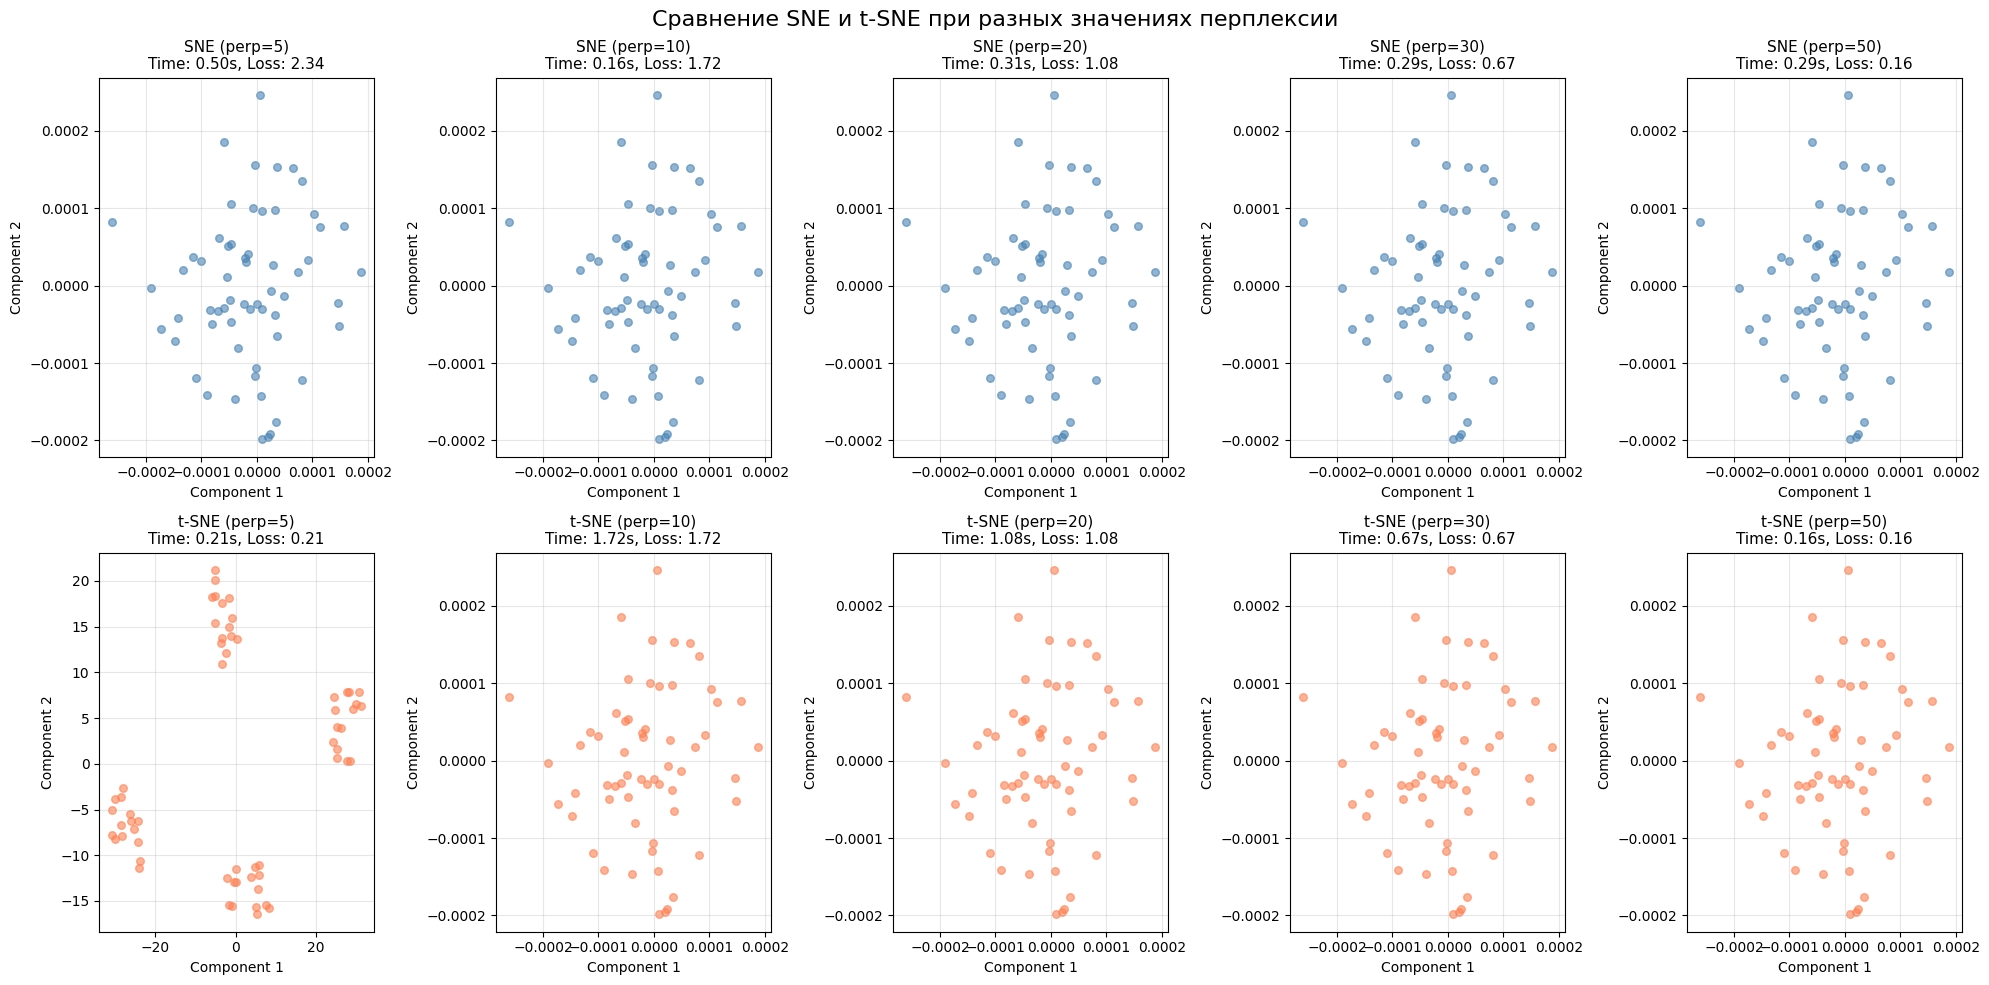

In [15]:
fig, axes = plt.subplots(2, len(perplexities), figsize=(20, 10))

for idx, perp in enumerate(perplexities):
    ax = axes[0, idx]
    Y = results['SNE'][perp]['embedding']
    t = results['SNE'][perp]['time']
    loss = results['SNE'][perp]['loss']
    ax.scatter(Y[:, 0], Y[:, 1], alpha=0.6, s=30, c='steelblue')
    ax.set_title(f'SNE (perp={perp})\nTime: {t:.2f}s, Loss: {loss:.2f}', fontsize=11)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

    ax = axes[1, idx]
    Y = results['t-SNE'][perp]['embedding']
    t = results['t-SNE'][perp]['loss']
    loss = results['t-SNE'][perp]['loss']
    ax.scatter(Y[:, 0], Y[:, 1], alpha=0.6, s=30, c='coral')
    ax.set_title(f't-SNE (perp={perp})\nTime: {t:.2f}s, Loss: {loss:.2f}', fontsize=11)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение SNE и t-SNE при разных значениях перплексии', fontsize=16)
plt.tight_layout()
plt.show()

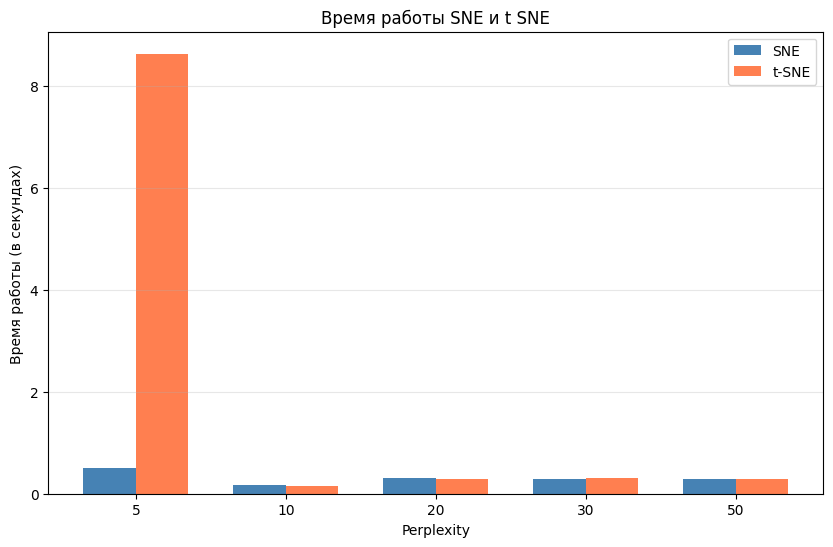

In [16]:
times_sne = [results['SNE'][p]['time'] for p in perplexities]
times_tsne = [results['t-SNE'][p]['time'] for p in perplexities]

plt.figure(figsize=(10, 6))
x = np.arange(len(perplexities))
width = 0.35

plt.bar(x - width/2, times_sne, width, label='SNE', color='steelblue')
plt.bar(x + width/2, times_tsne, width, label='t-SNE', color='coral')

plt.xlabel('Perplexity')
plt.ylabel('Время работы (в секундах)')
plt.title('Время работы SNE и t SNE')
plt.xticks(x, perplexities)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Замечание:** В качестве способа минимизации функции потерь можно использовать либо самостоятельно реализованный градиентный спуск, либо некоторую библиотечную оптимизацию, использующую вычисленные вами в предыдущей задаче градиенты функций потерь. Например, на основе `scipy.optimize.minimize`.

In [ ]:
# @title Пример использования scipy.optimize.minimize
import numpy as np
from scipy.optimize import minimize

# Пусть минимизируемая функция имеет вид $(x-2)^2 + (y+1)^2$
# Начальная точка
x0 = np.array([5,8])

# Для вычисления точки минимума в функцию minimize подается
# cама минимизируемая функция и ее градиент
def f_and_grad(point):
  x,y = point
  f = (x-2)**2 + (y+1)**2
  grad = np.array([2*(x-2), 2*(y+1)])
  return f, grad


# Чтобы функция minimize использовала именно наш градиент
# устанавливаем соответствующий параметр jac=True
minimize(f_and_grad, x0, jac=True)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.2960960997952e-29
        x: [ 2.000e+00 -1.000e+00]
      nit: 4
      jac: [ 1.510e-14 -4.885e-15]
 hess_inv: [[ 9.500e-01 -1.500e-01]
            [-1.500e-01  5.500e-01]]
     nfev: 5
     njev: 5

## Задача 2.2

Используя набор данных из Задачи 2.1 и [библиотечную реализацию t-SNE](https://opentsne.readthedocs.io/en/latest/api/sklearn.html), произведите численные эксперименты. Обратите особое внимание на следующие параметры: `perplexity, early_exaggeration, exaggeration, initialization, dof`. Сравните время работы и получаемые результаты с результатами Задачи 2.1. Сделайте выводы.

In [21]:
!pip install opentsne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 36.0 MB/s eta 0:00:00


In [22]:
from openTSNE import TSNE as OpenTSNE


perplexities = [5, 10, 20, 30, 50]
results_library = {}

for perp in perplexities:
    print(f"\nRunning openTSNE with perplexity={perp}...")
    start = time.time()

    tsne = OpenTSNE(
        n_components=2,
        perplexity=perp,
        n_iter=1000,
        random_state=1,
        early_exaggeration=12,
        exaggeration=None,
        initialization='pca',
        dof=1
    )

    Y_lib = tsne.fit(X_scaled)
    lib_time = time.time() - start

    results_library[perp] = {'embedding': Y_lib, 'time': lib_time}
    print(f"Time: {lib_time:.2f}s")


Running openTSNE with perplexity=5...
Time: 22.59s

Running openTSNE with perplexity=10...


Time: 0.23s

Running openTSNE with perplexity=20...


Time: 0.24s

Running openTSNE with perplexity=30...


Time: 0.25s

Running openTSNE with perplexity=50...
Time: 0.24s


In [24]:
param_experiments = {
    'default': {'perplexity': 30, 'early_exaggeration': 12, 'exaggeration': None,
                'initialization': 'pca', 'dof': 1},
    'low_perplexity': {'perplexity': 5, 'early_exaggeration': 12, 'exaggeration': None,
                       'initialization': 'pca', 'dof': 1},
    'high_perplexity': {'perplexity': 50, 'early_exaggeration': 12, 'exaggeration': None,
                        'initialization': 'pca', 'dof': 1},
    'low_early_exag': {'perplexity': 30, 'early_exaggeration': 1, 'exaggeration': None,
                       'initialization': 'pca', 'dof': 1},
    'high_early_exag': {'perplexity': 30, 'early_exaggeration': 24, 'exaggeration': None,
                        'initialization': 'pca', 'dof': 1},
    'random_init': {'perplexity': 30, 'early_exaggeration': 12, 'exaggeration': None,
                    'initialization': 'random', 'dof': 1},
    'high_dof': {'perplexity': 30, 'early_exaggeration': 12, 'exaggeration': None,
                 'initialization': 'pca', 'dof': 2},
    'with_exaggeration': {'perplexity': 30, 'early_exaggeration': 12, 'exaggeration': 2,
                          'initialization': 'pca', 'dof': 1}
}

results_params = {}

# Запуск экспериментов
for exp_name, exp_params in param_experiments.items():
    print(f"\n{'='*50}")
    print(f"Эксперимент: {exp_name}")
    print(f"{'='*50}")

    start_time = time.time()

    tsne_model = OpenTSNE(
        n_components=2,
        n_iter=1000,
        random_state=42,
        **exp_params
    )

    embedding_result = tsne_model.fit(X_scaled)

    elapsed_time = time.time() - start_time

    results_params[exp_name] = {
        'embedding': embedding_result,
        'time': elapsed_time,
        'params': exp_params
    }

    print(f"Время выполнения: {elapsed_time:.2f} сек")
    print(f"Параметры: перплексия={exp_params['perplexity']}, "
          f"раннее преувеличение={exp_params['early_exaggeration']}, "
          f"инициализация={exp_params['initialization']}")


Эксперимент: default
Время выполнения: 0.66 сек
Параметры: перплексия=30, раннее преувеличение=12, инициализация=pca

Эксперимент: low_perplexity


Время выполнения: 0.43 сек
Параметры: перплексия=5, раннее преувеличение=12, инициализация=pca

Эксперимент: high_perplexity


Время выполнения: 0.83 сек
Параметры: перплексия=50, раннее преувеличение=12, инициализация=pca

Эксперимент: low_early_exag


Время выполнения: 0.51 сек
Параметры: перплексия=30, раннее преувеличение=1, инициализация=pca

Эксперимент: high_early_exag


Время выполнения: 0.60 сек
Параметры: перплексия=30, раннее преувеличение=24, инициализация=pca

Эксперимент: random_init


Время выполнения: 0.46 сек
Параметры: перплексия=30, раннее преувеличение=12, инициализация=random

Эксперимент: high_dof


Время выполнения: 0.66 сек
Параметры: перплексия=30, раннее преувеличение=12, инициализация=pca

Эксперимент: with_exaggeration
Время выполнения: 0.49 сек
Параметры: перплексия=30, раннее преувеличение=12, инициализация=pca


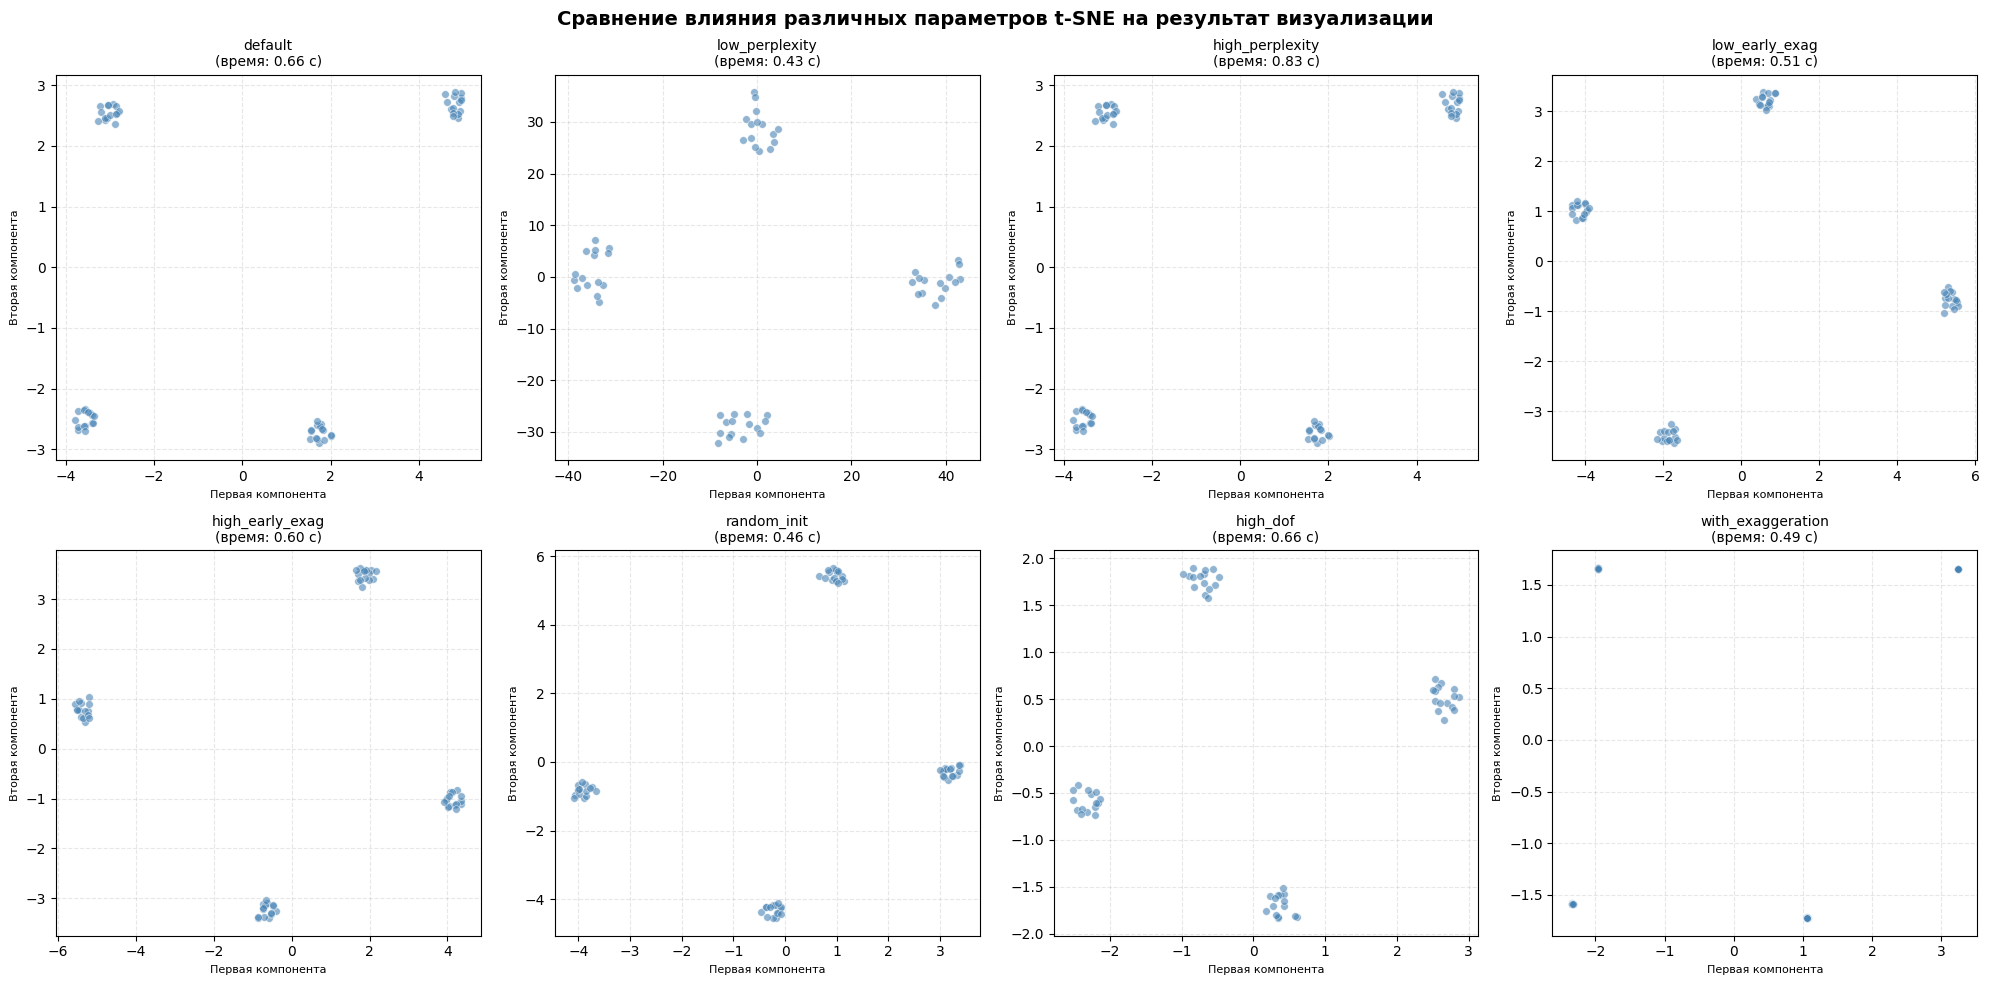

In [25]:
# Визуализация результатов экспериментов с параметрами
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for plot_idx, (exp_name, exp_result) in enumerate(results_params.items()):
    embedding_coords = exp_result['embedding']
    exec_time = exp_result['time']

    axes_flat[plot_idx].scatter(
        embedding_coords[:, 0],
        embedding_coords[:, 1],
        alpha=0.6,
        s=30,
        c='steelblue',
        edgecolors='white',
        linewidth=0.5
    )
    axes_flat[plot_idx].set_title(f'{exp_name}\n(время: {exec_time:.2f} с)', fontsize=10)
    axes_flat[plot_idx].set_xlabel('Первая компонента', fontsize=8)
    axes_flat[plot_idx].set_ylabel('Вторая компонента', fontsize=8)
    axes_flat[plot_idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Сравнение влияния различных параметров t-SNE на результат визуализации',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


СРАВНЕНИЕ ВРЕМЕНИ ВЫПОЛНЕНИЯ
 Перплексия  Наша реализация t-SNE (сек)  openTSNE (сек)
          5                     8.634769       22.593519
         10                     0.146685        0.234333
         20                     0.297877        0.240864
         30                     0.315135        0.249640
         50                     0.296771        0.238669


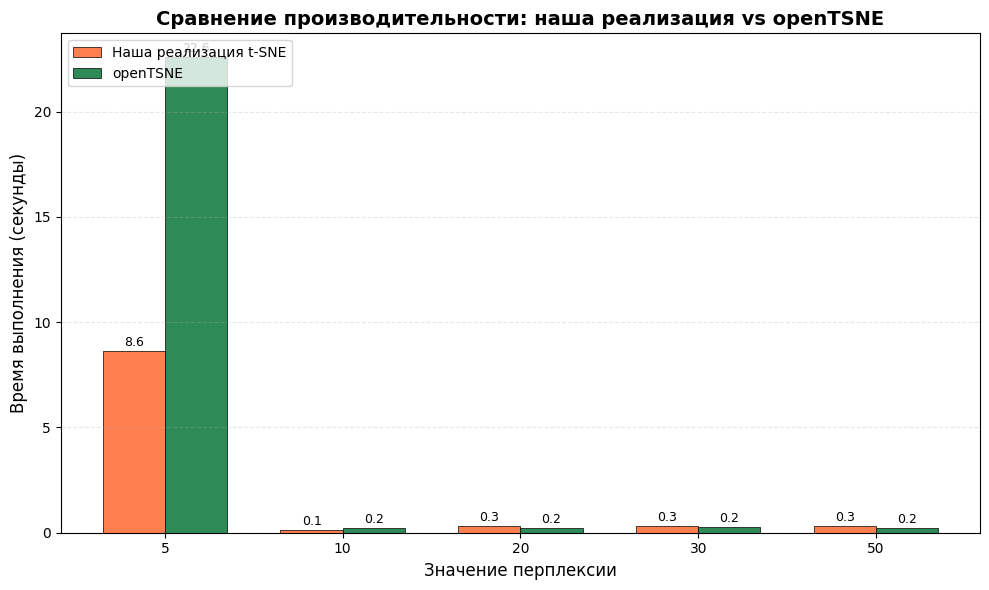

In [26]:
# Сбор данных для сравнения времени выполнения
time_comparison = []

for perplexity_value in [5, 10, 20, 30, 50]:
    time_comparison.append({
        'Перплексия': perplexity_value,
        'Наша реализация t-SNE (сек)': results['t-SNE'][perplexity_value]['time'],
        'openTSNE (сек)': results_library[perplexity_value]['time']
    })

comparison_dataframe = pd.DataFrame(time_comparison)

print("\n" + "="*60)
print("СРАВНЕНИЕ ВРЕМЕНИ ВЫПОЛНЕНИЯ")
print("="*60)
print(comparison_dataframe.to_string(index=False))
print("="*60)

# Построение гистограммы сравнения производительности
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(comparison_dataframe))
bar_width = 0.35

custom_bars = plt.bar(
    bar_positions - bar_width/2,
    comparison_dataframe['Наша реализация t-SNE (сек)'],
    bar_width,
    label='Наша реализация t-SNE',
    color='coral',
    edgecolor='black',
    linewidth=0.5
)

library_bars = plt.bar(
    bar_positions + bar_width/2,
    comparison_dataframe['openTSNE (сек)'],
    bar_width,
    label='openTSNE',
    color='seagreen',
    edgecolor='black',
    linewidth=0.5
)

plt.xlabel('Значение перплексии', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Сравнение производительности: наша реализация vs openTSNE', fontsize=14, fontweight='bold')
plt.xticks(bar_positions, comparison_dataframe['Перплексия'])
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# Добавление значений над столбцами
for bar in custom_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in library_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Задача 3

Проверьте свои выводы о влиянии рассмотренных в Задаче 2.2 параметров на результат, используя более объемный, как с точки зрения количества объектов, так и с точки зрения количества признаков, датасет на свой выбор.

In [33]:
from sklearn.datasets import make_blobs

# Генерируем датасет среднего размера: 1500 объектов, 20 признаков, 6 кластеров
X_medium, y_medium = make_blobs(
    n_samples=1500,      # количество объектов
    n_features=20,       # количество признаков
    centers=6,           # количество центров
    random_state=42,
    cluster_std=1.5      # небольшой разброс для реалистичности
)

X_medium_scaled = StandardScaler().fit_transform(X_medium)

print(f"Размер датасета: {X_medium_scaled.shape[0]} объектов, "
      f"{X_medium_scaled.shape[1]} признаков")
print(f"Количество кластеров: {len(np.unique(y_medium))}")

Размер датасета: 1500 объектов, 20 признаков
Количество кластеров: 6


In [34]:
#  Настройка параметров эксперимента
params_to_test = [
    {'perplexity': 5, 'early_exaggeration': 12, 'initialization': 'pca', 'dof': 1},
    {'perplexity': 30, 'early_exaggeration': 12, 'initialization': 'pca', 'dof': 1},
    {'perplexity': 50, 'early_exaggeration': 12, 'initialization': 'pca', 'dof': 1},
    {'perplexity': 30, 'early_exaggeration': 1, 'initialization': 'pca', 'dof': 1},
    {'perplexity': 30, 'early_exaggeration': 24, 'initialization': 'pca', 'dof': 1},
    {'perplexity': 30, 'early_exaggeration': 12, 'initialization': 'random', 'dof': 1},
    {'perplexity': 30, 'early_exaggeration': 12, 'initialization': 'pca', 'dof': 2},
    {'perplexity': 30, 'early_exaggeration': 12, 'exaggeration': 2, 'initialization': 'pca', 'dof': 1}
]

param_labels = ['perp=5', 'perp=30', 'perp=50', 'early_exag=1',
                'early_exag=24', 'random_init', 'dof=2', 'exaggeration=2']

experiment_results = []

#Запуск экспериментов
for test_params, param_label in zip(params_to_test, param_labels):
    print(f"\nЗапуск: {param_label}")
    start_time = time.time()

    tsne_model = OpenTSNE(
        n_components=2,
        n_iter=500,
        random_state=1,
        **test_params
    )

    low_dim_points = tsne_model.fit(X_medium_scaled)
    elapsed_time = time.time() - start_time

    experiment_results.append({
        'label': param_label,
        'embedding': low_dim_points,
        'time': elapsed_time
    })
    print(f"Время: {elapsed_time:.2f}с")


Запуск: perp=5
Время: 7.50с

Запуск: perp=30
Время: 5.16с

Запуск: perp=50
Время: 6.41с

Запуск: early_exag=1
Время: 5.06с

Запуск: early_exag=24
Время: 5.68с

Запуск: random_init
Время: 8.62с

Запуск: dof=2
Время: 13.35с

Запуск: exaggeration=2
Время: 5.86с


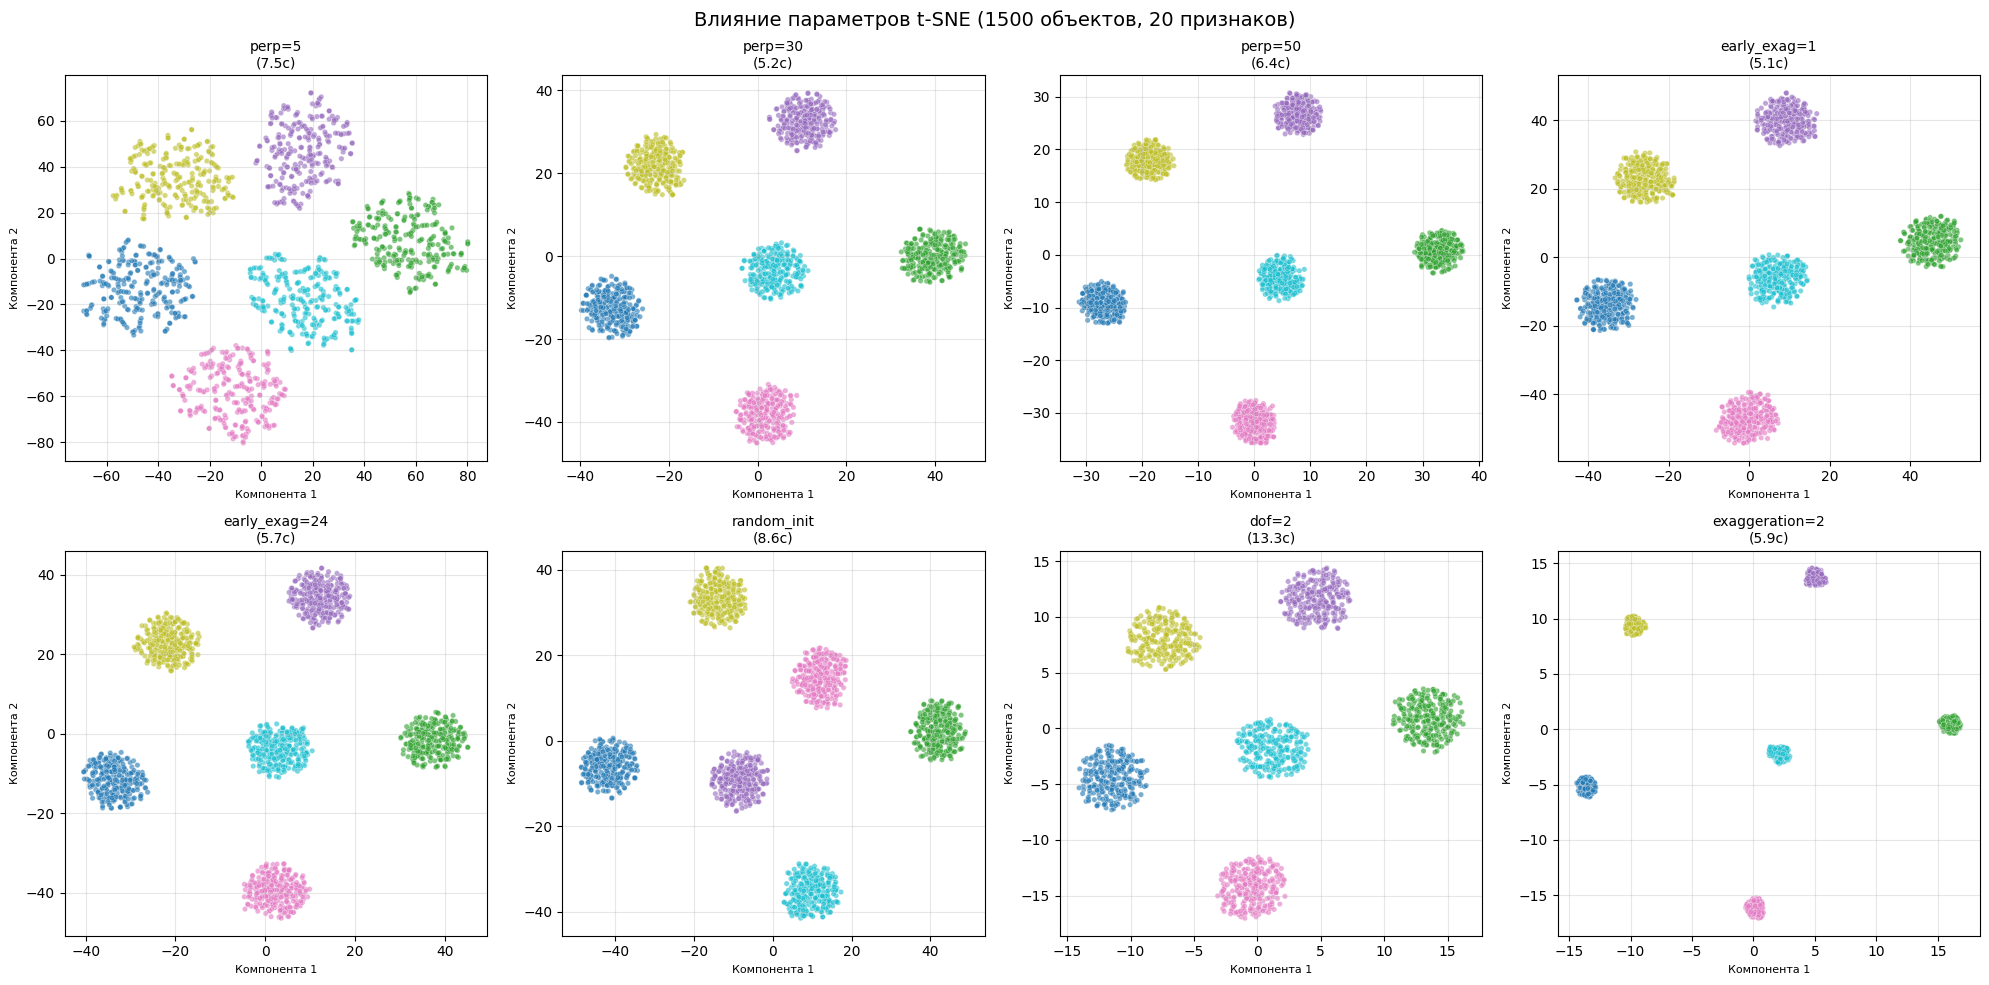


Время выполнения на новом датасете:
perp=5               7.50 сек
perp=30              5.16 сек
perp=50              6.41 сек
early_exag=1         5.06 сек
early_exag=24        5.68 сек
random_init          8.62 сек
dof=2                13.35 сек
exaggeration=2       5.86 сек


In [35]:
#Визуализация
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for plot_idx, exp_result in enumerate(experiment_results):
    coordinates = exp_result['embedding']
    exec_time = exp_result['time']

    axes_flat[plot_idx].scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=y_medium,
        alpha=0.6,
        s=15,
        cmap='tab10',
        edgecolors='white',
        linewidth=0.3
    )
    axes_flat[plot_idx].set_title(f'{exp_result["label"]}\n({exec_time:.1f}с)', fontsize=10)
    axes_flat[plot_idx].set_xlabel('Компонента 1', fontsize=8)
    axes_flat[plot_idx].set_ylabel('Компонента 2', fontsize=8)
    axes_flat[plot_idx].grid(True, alpha=0.3)

plt.suptitle('Влияние параметров t-SNE (1500 объектов, 20 признаков)', fontsize=14)
plt.tight_layout()
plt.show()

#Сравнение времени
print("\n" + "="*50)
print("Время выполнения на новом датасете:")
print("="*50)
for exp_result in experiment_results:
    print(f"{exp_result['label']:<20} {exp_result['time']:.2f} сек")